In [15]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error

In [4]:
DATA_PATH = Path("../data/processed/sardinia_hourly.parquet")
df = pd.read_parquet(DATA_PATH)

display(df.head())

,Total Load [MW],Forecast Total Load [MW]
Date,,
2023-01-01 00:00:00+01:00,806.13675,833.01000
2023-01-01 01:00:00+01:00,783.55525,779.20525
2023-01-01 02:00:00+01:00,753.62675,749.15025
2023-01-01 03:00:00+01:00,736.34950,739.18250
2023-01-01 04:00:00+01:00,723.29950,749.01150


In [ ]:
baseline_df = df.copy()

baseline_df["Baseline 24h"] = baseline_df["Total Load [MW]"].shift(24)
baseline_df["Baseline 168h"] = baseline_df["Total Load [MW]"].shift(168)

baseline_df[
    ["Total Load [MW]", "Baseline 24h", "Baseline 168h"]
].isna().sum()

In [10]:
train = baseline_df.loc[:"2025-12-31 23:59:59"].copy()
test = baseline_df.loc["2026-01-01":].copy()

print(f"Train: {train.index.min()} -> {train.index.max()} ({len(train):,} rows)")
print(f"Test:  {test.index.min()} -> {test.index.max()} ({len(test):,} rows)")

Train: 2023-01-01 00:00:00+01:00 -> 2025-12-31 23:00:00+01:00 (26,304 rows)
Test:  2026-01-01 00:00:00+01:00 -> 2026-10-05 23:00:00+02:00 (6,671 rows)


In [11]:
eval_df = test[
    [
        "Total Load [MW]",
        "Baseline 24h",
        "Baseline 168h",
        "Forecast Total Load [MW]"
    ]
].dropna()

print(f"Test rows:       {len(test):,}")
print(f"Evaluation rows: {len(eval_df):,}")
print(f"Excluded rows:   {len(test) - len(eval_df):,}")

Test rows:       6,671
Evaluation rows: 6,551
Excluded rows:   120


In [12]:
mae_24h = mean_absolute_error(
    eval_df["Total Load [MW]"],
    eval_df["Baseline 24h"]
)

mae_168h = mean_absolute_error(
    eval_df["Total Load [MW]"],
    eval_df["Baseline 168h"]
)

print(f"MAE 24h:  {mae_24h:.2f} MW")
print(f"MAE 168h: {mae_168h:.2f} MW")

MAE 24h:  44.90 MW
MAE 168h: 63.63 MW


In [14]:
rmse_24h = root_mean_squared_error(
    eval_df["Total Load [MW]"],
    eval_df["Baseline 24h"]
)

rmse_168h = root_mean_squared_error(
    eval_df["Total Load [MW]"],
    eval_df["Baseline 168h"]
)

print(f"RMSE 24h:  {rmse_24h:.2f} MW")
print(f"RMSE 168h: {rmse_168h:.2f} MW")

RMSE 24h:  63.85 MW
RMSE 168h: 89.37 MW


In [16]:
mape_24h = mean_absolute_percentage_error(
    eval_df["Total Load [MW]"],
    eval_df["Baseline 24h"]
) * 100

mape_168h = mean_absolute_percentage_error(
    eval_df["Total Load [MW]"],
    eval_df["Baseline 168h"]
) * 100

print(f"MAPE 24h:  {mape_24h:.2f}%")
print(f"MAPE 168h: {mape_168h:.2f}%")

MAPE 24h:  4.32%
MAPE 168h: 5.98%


In [17]:
mae_terna = mean_absolute_error(
    eval_df["Total Load [MW]"],
    eval_df["Forecast Total Load [MW]"]
)

print(f"MAE Terna: {mae_terna:.2f} MW")

MAE Terna: 16.23 MW


In [18]:
rmse_terna = root_mean_squared_error(
    eval_df["Total Load [MW]"],
    eval_df["Forecast Total Load [MW]"]
)

print(f"RMSE Terna: {rmse_terna:.2f} MW")

RMSE Terna: 22.87 MW


In [21]:
mape_terna = mean_absolute_percentage_error(
    eval_df["Total Load [MW]"],
    eval_df["Forecast Total Load [MW]"]
) * 100

print(f"MAPE Terna: {mape_terna:.2f} %")

MAPE Terna: 1.55 %


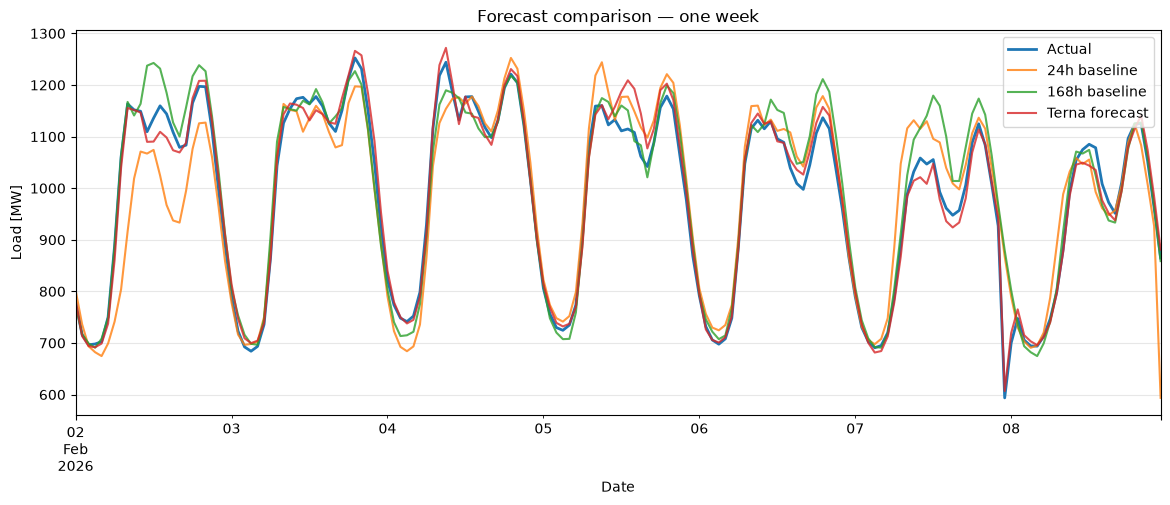

In [22]:
week = eval_df.loc["2026-02-02":"2026-02-08"]

fig, ax = plt.subplots(figsize=(14, 5))

week["Total Load [MW]"].plot(ax=ax, label="Actual", linewidth=2)
week["Baseline 24h"].plot(ax=ax, label="24h baseline", alpha=0.8)
week["Baseline 168h"].plot(ax=ax, label="168h baseline", alpha=0.8)
week["Forecast Total Load [MW]"].plot(ax=ax, label="Terna forecast", alpha=0.8)

ax.set_title("Forecast comparison — one week")
ax.set_xlabel("Date")
ax.set_ylabel("Load [MW]")
ax.legend()
ax.grid(alpha=0.3)

plt.show()